In [3]:
import requests
from requests.packages.urllib3.exceptions import InsecureRequestWarning

# Silenciar las advertencias de conexión insegura
requests.packages.urllib3.disable_warnings(InsecureRequestWarning)
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from tqdm import tqdm

API_URL = "https://rsm.ane.gov.co:12443/api"

camp_ids = {'10K': 189, '30K': 190, '100K': 191, '3K': 193}
macs_node = {
    '1': 'd8:3a:dd:f7:1d:f2', '3': 'd8:3a:dd:f7:22:87', 
    '4': 'd8:3a:dd:f6:fc:be', '5': 'd8:3a:dd:f7:21:52', 
    '9': 'd8:3a:dd:f4:4e:d1'
}

def get_api_signals(mac, camp_id):
    url = f"{API_URL}/campaigns/sensor/{mac}/signals"
    params = {"campaign_id": camp_id, "page": 1, "page_size": 5000}
    signals = []
    
    while True:
        data = requests.get(url, params=params, verify=False).json()
        signals.extend(data['measurements'])
        
        if not data['pagination']['has_next']:
            break
        params['page'] += 1
        
    return signals

# 1. CARGA DIRECTA
df_full = {rbw: {} for rbw in camp_ids}

with tqdm(total=len(camp_ids) * len(macs_node), desc="Descargando API") as pbar:
    for rbw, camp_id in camp_ids.items():
        for node, mac in macs_node.items():
            datos = get_api_signals(mac, camp_id)
            if datos:
                df = pd.DataFrame(datos)
                df = df.dropna(subset=['pxx'])
                df_full[rbw][f"Node{node}"] = df
            pbar.update(1)

Descargando API: 100%|██████████| 20/20 [00:08<00:00,  2.44it/s]


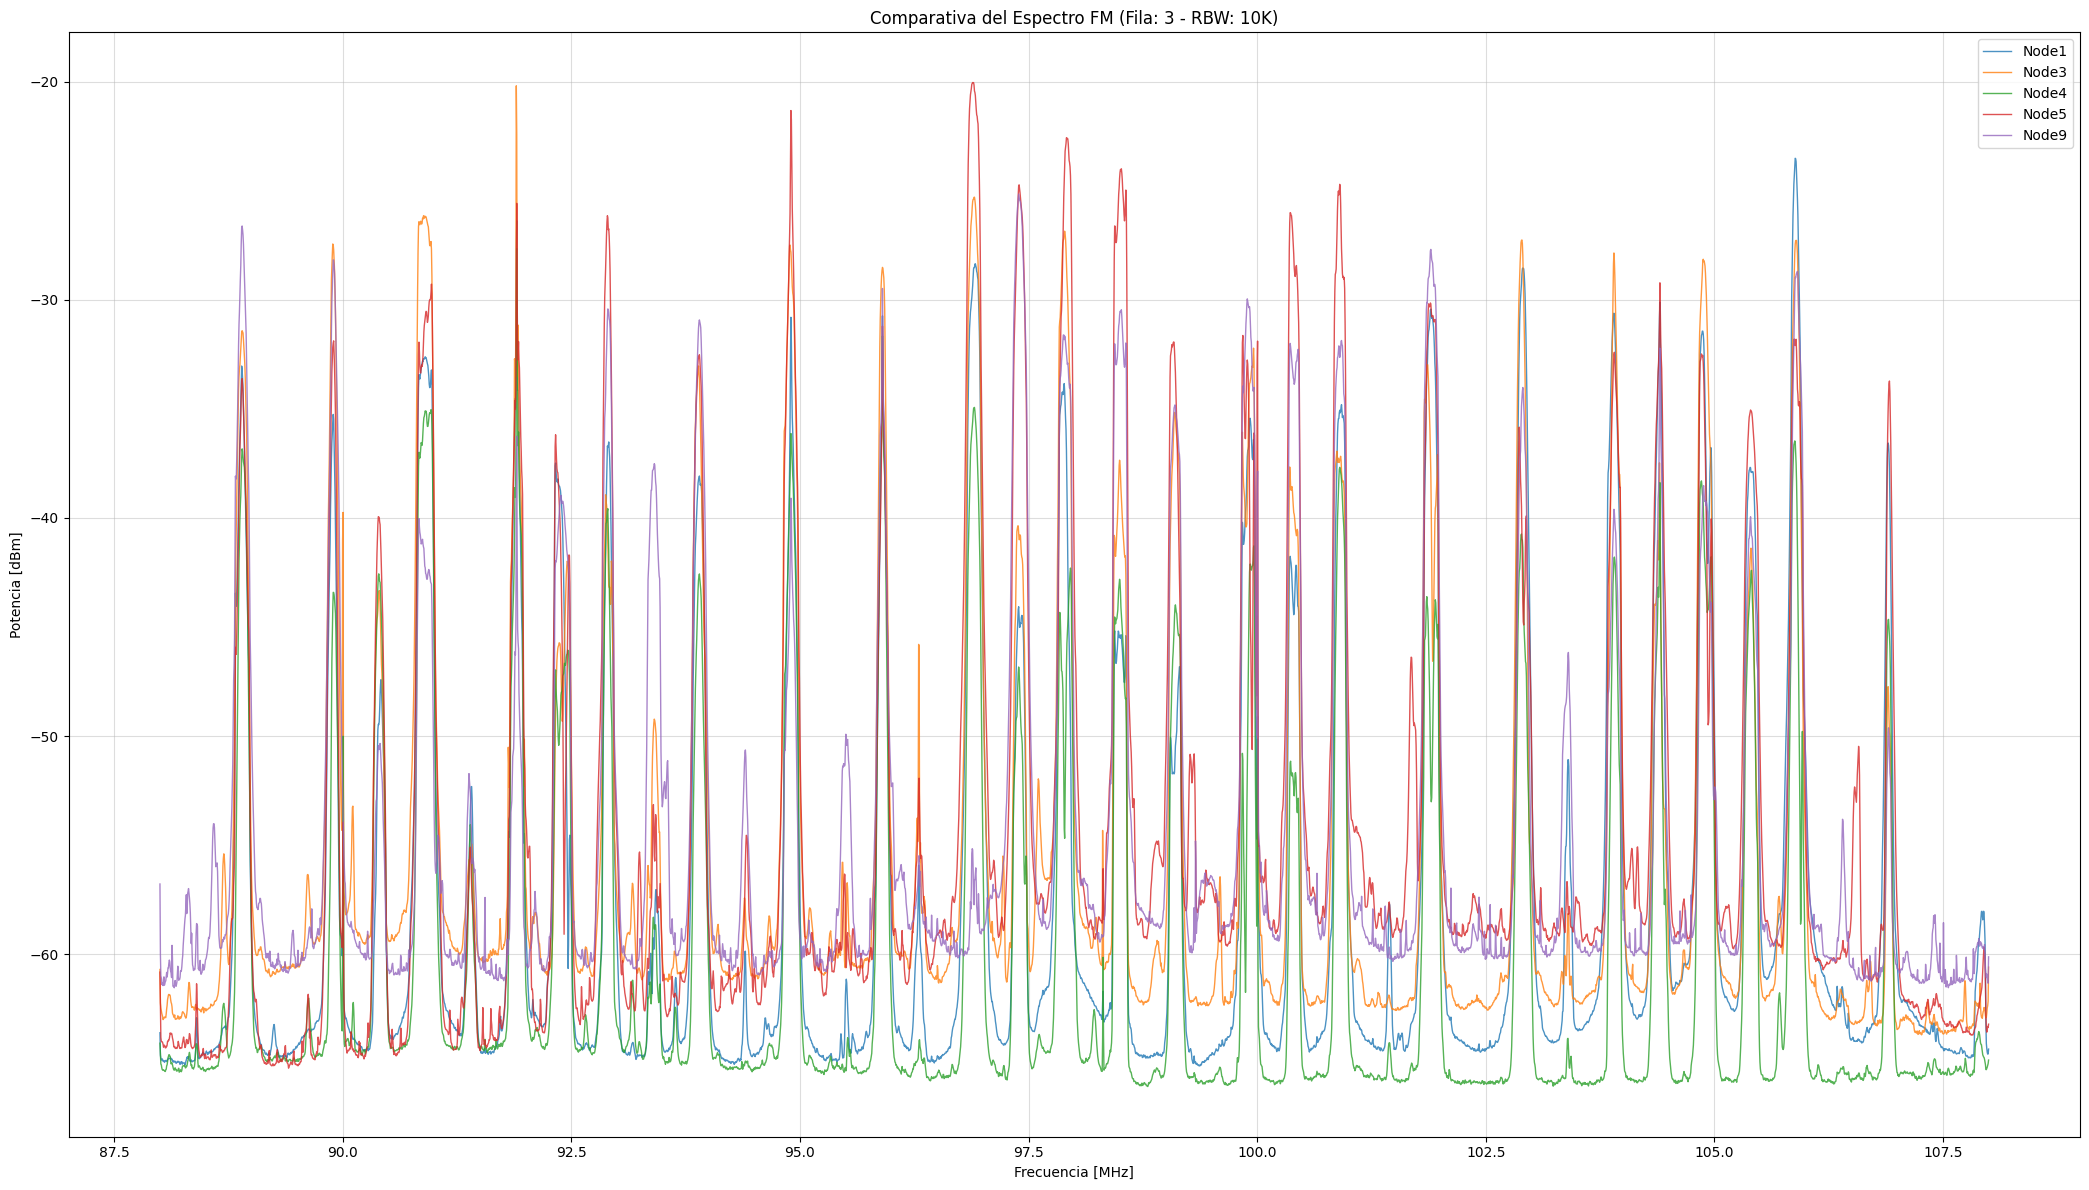

In [4]:
# 2. GRÁFICA
RBW = "10K"  
datos_nodos = df_full[RBW]
ROW_PLOT = 3  

plt.figure(figsize=(21, 12))

for nombre_nodo, df in datos_nodos.items():
    if ROW_PLOT < len(df):
        fila = df.iloc[ROW_PLOT]
        pxx = fila['pxx']
        
        # Aprovechamos las frecuencias reales del payload
        f_start = fila['start_freq_hz'] / 1e6
        f_end = fila['end_freq_hz'] / 1e6
        frecuencias = np.linspace(f_start, f_end, len(pxx))
        
        plt.plot(frecuencias, pxx, label=nombre_nodo, linewidth=1, alpha=0.8)

plt.title(f"Comparativa del Espectro FM (Fila: {ROW_PLOT} - RBW: {RBW})")
plt.xlabel("Frecuencia [MHz]")
plt.ylabel("Potencia [dBm]")
# plt.xlim(97, 99) # Descomenta si quieres el zoom específico
plt.legend(loc='best')
plt.grid(True, alpha=0.42)
plt.tight_layout()
plt.show()